In [ ]:
#smote et adasyn

In [45]:
# ============================================================
# STRATÉGIE 2 - BLOC 1: EXTRACTION DES EMBEDDINGS [CLS]
# ============================================================
# Objectif: Convertir chaque tweet en vecteur numérique de 768 dimensions
# Le vecteur [CLS] capture le sens global du tweet
# ============================================================

import torch
import numpy as np
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm
import pickle
from google.colab import drive

print("="*70)
print("STRATÉGIE 2: RÉÉQUILIBRAGE DANS L'ESPACE DES EMBEDDINGS")
print("="*70)

# Monter Google Drive pour sauvegarde
drive.mount('/content/drive')

# ============================================================
# 1. CHARGEMENT DU MODÈLE DZIRIBERT (sans tête de classification)
# ============================================================

print("\n1. Chargement de DziriBERT en mode extraction...")

model_name = "alger-ia/dziribert"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

# Mettre le modèle en mode évaluation (pas d'entraînement)
model.eval()

# Déplacer sur GPU si disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(f"   Modèle sur: {device}")

# ============================================================
# 2. FONCTION D'EXTRACTION DU VECTEUR [CLS]
# ============================================================

def extract_cls_embedding(text, tokenizer, model, device):
    """
    Extrait le vecteur [CLS] pour un texte donné
    Le vecteur [CLS] est une représentation globale du tweet (768 dimensions)
    """
    # Tokenisation
    inputs = tokenizer(
        text,
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )

    # Déplacer sur GPU
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Extraction sans calcul de gradient (plus rapide)
    with torch.no_grad():
        outputs = model(**inputs)

    # Le vecteur [CLS] est le premier token de la séquence
    cls_embedding = outputs.last_hidden_state[:, 0, :].cpu().numpy()

    return cls_embedding[0]

# ============================================================
# 3. EXTRACTION POUR TOUT LE TRAIN SET
# ============================================================

print("\n2. Extraction des embeddings [CLS] pour le train set...")
print(f"   Nombre de tweets à traiter: {len(train_set)}")

# Récupérer les textes et labels du train set
train_texts = train_set['clean_text'].tolist()
train_labels = train_set['Polarity Class'].tolist()

# Extraire les embeddings un par un
train_embeddings = []
valid_indices = []

for idx, text in enumerate(tqdm(train_texts, desc="Extraction embeddings")):
    try:
        embedding = extract_cls_embedding(text, tokenizer, model, device)
        train_embeddings.append(embedding)
        valid_indices.append(idx)
    except Exception as e:
        print(f"   Erreur sur tweet {idx}: {e}")
        continue

# Convertir en numpy array
X_train_emb = np.array(train_embeddings)
y_train_emb = np.array([train_labels[i] for i in valid_indices])

print(f"\n   ✓ Embeddings extraits: {X_train_emb.shape}")
print(f"     - {X_train_emb.shape[0]} tweets")
print(f"     - {X_train_emb.shape[1]} dimensions par tweet")

# ============================================================
# 4. VÉRIFICATION DE LA DISTRIBUTION
# ============================================================

print("\n3. Distribution des classes dans les embeddings:")
unique, counts = np.unique(y_train_emb, return_counts=True)
for label, count in zip(unique, counts):
    print(f"   {label}: {count} tweets ({count/len(y_train_emb)*100:.1f}%)")

# ============================================================
# 5. SAUVEGARDE DES EMBEDDINGS (pour éviter de refaire)
# ============================================================

print("\n4. Sauvegarde des embeddings...")

with open('/content/drive/MyDrive/train_embeddings.pkl', 'wb') as f:
    pickle.dump({
        'embeddings': X_train_emb,
        'labels': y_train_emb,
        'texts': [train_texts[i] for i in valid_indices]
    }, f)

print("   ✓ Embeddings sauvegardés dans Google Drive")

print("\n" + "="*70)
print("BLOC 1 TERMINÉ - Embeddings prêts pour SMOTE/ADASYN")
print("="*70)

STRATÉGIE 2: RÉÉQUILIBRAGE DANS L'ESPACE DES EMBEDDINGS
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

1. Chargement de DziriBERT en mode extraction...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: alger-ia/dziribert
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
pooler.dense.bias                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


   Modèle sur: cuda

2. Extraction des embeddings [CLS] pour le train set...
   Nombre de tweets à traiter: 3369


Extraction embeddings: 100%|██████████| 3369/3369 [00:32<00:00, 102.32it/s]


   ✓ Embeddings extraits: (3369, 768)
     - 3369 tweets
     - 768 dimensions par tweet

3. Distribution des classes dans les embeddings:
   Negative: 1198 tweets (35.6%)
   Neutral: 442 tweets (13.1%)
   Positive: 1729 tweets (51.3%)

4. Sauvegarde des embeddings...
   ✓ Embeddings sauvegardés dans Google Drive

BLOC 1 TERMINÉ - Embeddings prêts pour SMOTE/ADASYN


SMOTE - TESTS COMPLETS (Équilibre total vs partiel)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: alger-ia/dziribert
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
pooler.dense.bias                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Extracting embeddings for validation set...


Val Embeddings: 100%|██████████| 722/722 [00:07<00:00, 102.20it/s]



Extracting embeddings for test set...


Test Embeddings: 100%|██████████| 722/722 [00:07<00:00, 99.94it/s] 



Encoding labels...

TEST 1: SMOTE - ÉQUILIBRE TOTAL
Distribution après SMOTE total:
  Negative: 1729
  Neutral: 1729
  Positive: 1729

Résultats SMOTE équilibre total:
  F1-macro: 0.6679
  F1-Neutral: 0.5405

TEST 2: SMOTE - ÉQUILIBRE PARTIEL (Neutral à 25%)
Stratégie d'échantillonnage:
  Negative: 1198 (conservé)
  Neutral: 842 (augmenté à 25% du total)
  Positive: 1729 (conservé)

Distribution après SMOTE partiel:
  Negative: 1198
  Neutral: 842
  Positive: 1729

Résultats SMOTE équilibre partiel:
  F1-macro: 0.6828
  F1-Neutral: 0.5734

TEST 3: SMOTE - k_neighbors variables

▶ Test avec k = 3
    F1-macro: 0.6617
    F1-Neutral: 0.5298

▶ Test avec k = 5
    F1-macro: 0.6679
    F1-Neutral: 0.5405

▶ Test avec k = 7
    F1-macro: 0.6730
    F1-Neutral: 0.5563

▶ Test avec k = 9
    F1-macro: 0.6716
    F1-Neutral: 0.5541

TABLEAU COMPARATIF - SMOTE
          Configuration  F1-macro  F1-Neutral
               Baseline  0.672674    0.552083
SMOTE (équilibre total)  0.667886    0.5405

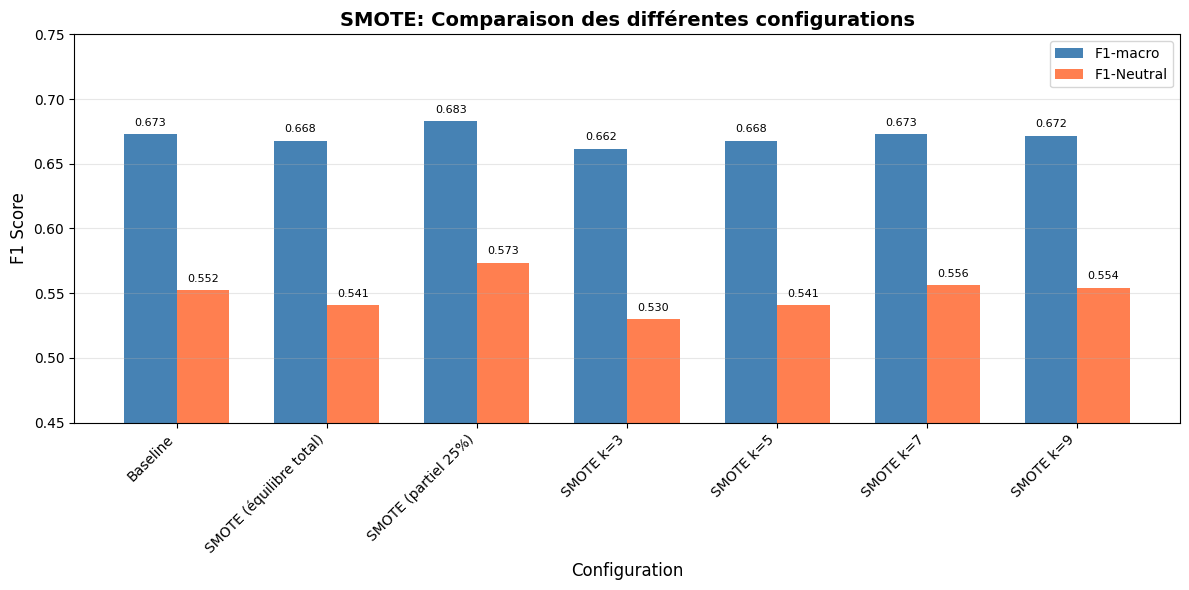


✓ Résultats SMOTE sauvegardés


In [46]:
# ============================================================
# SMOTE
# ============================================================

from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC
from sklearn.metrics import f1_score, classification_report
import pandas as pd
import numpy as np
import pickle
import torch
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm


print("="*70)
print("SMOTE - TESTS COMPLETS (Équilibre total vs partiel)")
print("="*70)

# Re-load or re-define necessary components from previous cells
# Assuming `train_set`, `val_set`, `test_set` DataFrames are available from previous cells.
# And `extract_cls_embedding` function, `tokenizer`, `model`, `device` are defined in the preceding cell (`qKK5Nn8ZS_Cc`).

# Load the saved train embeddings
with open('/content/drive/MyDrive/train_embeddings.pkl', 'rb') as f:
    train_data = pickle.load(f)
X_train_emb = train_data['embeddings']
y_train_emb = train_data['labels']

# Ensure tokenizer, model, device are ready for new extractions if needed
# This part assumes `qKK5Nn8ZS_Cc` was executed and these are in scope.
# If not, they would need to be re-initialized here.
model_name = "alger-ia/dziribert"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

def extract_cls_embedding(text, tokenizer, model, device):
    inputs = tokenizer(text, padding=True, truncation=True, max_length=128, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.last_hidden_state[:, 0, :].cpu().numpy()[0]

# Extract embeddings for validation and test sets
print("\nExtracting embeddings for validation set...")
val_embeddings = []
for text in tqdm(val_set['clean_text'].tolist(), desc="Val Embeddings"):
    val_embeddings.append(extract_cls_embedding(text, tokenizer, model, device))
X_val_emb = np.array(val_embeddings)
y_val_emb = val_set['Polarity Class'].tolist()

print("\nExtracting embeddings for test set...")
test_embeddings = []
for text in tqdm(test_set['clean_text'].tolist(), desc="Test Embeddings"):
    test_embeddings.append(extract_cls_embedding(text, tokenizer, model, device))
X_test_emb = np.array(test_embeddings)
y_test_emb = test_set['Polarity Class'].tolist()

# Encode labels
print("\nEncoding labels...")
le = LabelEncoder()
y_encoded = le.fit_transform(y_train_emb)
y_val_encoded = le.transform(y_val_emb)
y_test_encoded = le.transform(y_test_emb)

# 1. Normalisation des embeddings (obligatoire pour SMOTE)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_emb)
X_test_scaled = scaler.transform(X_test_emb)
X_val_scaled = scaler.transform(X_val_emb)

# ============================================================
# TEST 1: SMOTE avec équilibre TOTAL (33% par classe)
# ============================================================

print("\n" + "="*50)
print("TEST 1: SMOTE - ÉQUILIBRE TOTAL")
print("="*50)

smote_total = SMOTE(random_state=42, sampling_strategy='auto')
X_smote_total, y_smote_total = smote_total.fit_resample(X_train_scaled, y_encoded)

print(f"Distribution après SMOTE total:")
unique, counts = np.unique(y_smote_total, return_counts=True)
for label, count in zip(unique, counts):
    print(f"  {le.inverse_transform([label])[0]}: {count}")

# Entraînement SVM
svm_total = SVC(kernel='rbf', C=1.0, random_state=42)
svm_total.fit(X_smote_total, y_smote_total)

# Évaluation
y_pred_total = svm_total.predict(X_test_scaled)
f1_neutral_total = f1_score(y_test_encoded, y_pred_total, average=None)[1]
f1_macro_total = f1_score(y_test_encoded, y_pred_total, average='macro')

print(f"\nRésultats SMOTE équilibre total:")
print(f"  F1-macro: {f1_macro_total:.4f}")
print(f"  F1-Neutral: {f1_neutral_total:.4f}")

# ============================================================
# TEST 2: SMOTE avec équilibre PARTIEL (Neutral à 25%)
# ============================================================

print("\n" + "="*50)
print("TEST 2: SMOTE - ÉQUILIBRE PARTIEL (Neutral à 25%)")
print("="*50)

# Calculer combien de Neutral on veut (25% du total après augmentation)
current_counts = {i: np.sum(y_encoded == i) for i in range(3)}
current_total = sum(current_counts.values())
target_neutral = int(current_total * 0.25)  # 25% de Neutral
target_negative = current_counts[0]        # Garder Negative identique
target_positive = current_counts[2]        # Garder Positive identique

sampling_strategy_partial = {
    0: target_negative,
    1: target_neutral,
    2: target_positive
}

print(f"Stratégie d'échantillonnage:")
print(f"  Negative: {target_negative} (conservé)")
print(f"  Neutral: {target_neutral} (augmenté à 25% du total)")
print(f"  Positive: {target_positive} (conservé)")

smote_partial = SMOTE(random_state=42, sampling_strategy=sampling_strategy_partial)
X_smote_partial, y_smote_partial = smote_partial.fit_resample(X_train_scaled, y_encoded)

print(f"\nDistribution après SMOTE partiel:")
unique, counts = np.unique(y_smote_partial, return_counts=True)
for label, count in zip(unique, counts):
    print(f"  {le.inverse_transform([label])[0]}: {count}")

# Entraînement
svm_partial = SVC(kernel='rbf', C=1.0, random_state=42)
svm_partial.fit(X_smote_partial, y_smote_partial)

# Évaluation
y_pred_partial = svm_partial.predict(X_test_scaled)
f1_neutral_partial = f1_score(y_test_encoded, y_pred_partial, average=None)[1]
f1_macro_partial = f1_score(y_test_encoded, y_pred_partial, average='macro')

print(f"\nRésultats SMOTE équilibre partiel:")
print(f"  F1-macro: {f1_macro_partial:.4f}")
print(f"  F1-Neutral: {f1_neutral_partial:.4f}")

# ============================================================
# TEST 3: TEST AVEC DIFFÉRENTS k_neighbors
# ============================================================

print("\n" + "="*50)
print("TEST 3: SMOTE - k_neighbors variables")
print("="*50)

k_values = [3, 5, 7, 9]
k_results = []

for k in k_values:
    print(f"\n▶ Test avec k = {k}")

    smote_k = SMOTE(random_state=42, k_neighbors=k, sampling_strategy='auto')
    X_smote_k, y_smote_k = smote_k.fit_resample(X_train_scaled, y_encoded)

    svm_k = SVC(kernel='rbf', C=1.0, random_state=42)
    svm_k.fit(X_smote_k, y_smote_k)

    y_pred_k = svm_k.predict(X_test_scaled)
    f1_neutral_k = f1_score(y_test_encoded, y_pred_k, average=None)[1]
    f1_macro_k = f1_score(y_test_encoded, y_pred_k, average='macro')

    k_results.append({
        'k': k,
        'f1_macro': f1_macro_k,
        'f1_neutral': f1_neutral_k
    })

    print(f"    F1-macro: {f1_macro_k:.4f}")
    print(f"    F1-Neutral: {f1_neutral_k:.4f}")

# ============================================================
# TABLEAU COMPARATIF COMPLET SMOTE
# ============================================================

print("\n" + "="*70)
print("TABLEAU COMPARATIF - SMOTE")
print("="*70)

# Charger baseline
import json
with open('baseline_results.json', 'r') as f:
    baseline = json.load(f)

smote_comparison = pd.DataFrame({
    'Configuration': [
        'Baseline',
        'SMOTE (équilibre total)',
        'SMOTE (partiel 25%)',
        'SMOTE k=3',
        'SMOTE k=5',
        'SMOTE k=7',
        'SMOTE k=9'
    ],
    'F1-macro': [
        baseline['f1_macro'],
        f1_macro_total,
        f1_macro_partial,
        k_results[0]['f1_macro'],
        k_results[1]['f1_macro'],
        k_results[2]['f1_macro'],
        k_results[3]['f1_macro']
    ],
    'F1-Neutral': [
        baseline['f1_neutral'],
        f1_neutral_total,
        f1_neutral_partial,
        k_results[0]['f1_neutral'],
        k_results[1]['f1_neutral'],
        k_results[2]['f1_neutral'],
        k_results[3]['f1_neutral']
    ]
})

print(smote_comparison.to_string(index=False))

# ============================================================
# GRAPHIQUE COMPARATIF
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

configs = smote_comparison['Configuration'].tolist()
f1_macro_values = smote_comparison['F1-macro'].tolist()
f1_neutral_values = smote_comparison['F1-Neutral'].tolist()

x = np.arange(len(configs))
width = 0.35

bars1 = ax.bar(x - width/2, f1_macro_values, width, label='F1-macro', color='steelblue')
bars2 = ax.bar(x + width/2, f1_neutral_values, width, label='F1-Neutral', color='coral')

ax.set_xlabel('Configuration', fontsize=12)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('SMOTE: Comparaison des différentes configurations', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(configs, rotation=45, ha='right')
ax.legend()
ax.set_ylim(0.45, 0.75)
ax.grid(axis='y', alpha=0.3)

# Ajouter les valeurs
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Sauvegarde des résultats SMOTE
smote_all_results = {
    'equilibre_total': {
        'f1_macro': f1_macro_total,
        'f1_neutral': f1_neutral_total
    },
    'equilibre_partiel_25': {
        'f1_macro': f1_macro_partial,
        'f1_neutral': f1_neutral_partial
    },
    'k_neighbors': {f"k={k['k']}": {'f1_macro': k['f1_macro'], 'f1_neutral': k['f1_neutral']} for k in k_results}
}

with open('/content/drive/MyDrive/smote_all_results.json', 'w') as f:
    json.dump(smote_all_results, f, indent=4)

print("\n✓ Résultats SMOTE sauvegardés")

In [47]:
# ============================================================
# ADASYN
# ============================================================

from imblearn.over_sampling import ADASYN
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import f1_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import pickle
from google.colab import drive
from tqdm import tqdm
import torch
from transformers import AutoTokenizer, AutoModel

drive.mount('/content/drive')

# ============================================================
# ÉTAPE 1: CHARGEMENT ET NETTOYAGE
# ============================================================

print("="*70)
print("ADASYN - AVEC CORRECTIONS NaN")
print("="*70)

# Charger les splits
train_set = pd.read_csv('/content/drive/MyDrive/train_set.csv')
val_set = pd.read_csv('/content/drive/MyDrive/val_set.csv')
test_set = pd.read_csv('/content/drive/MyDrive/test_set.csv')

# Nettoyer toutes les colonnes clean_text
for df in [train_set, val_set, test_set]:
    df['clean_text'] = df['clean_text'].fillna('').astype(str)
    df['clean_text'] = df['clean_text'].apply(lambda x: x if x.strip() != '' else None)

# Supprimer les lignes avec None
train_set = train_set[train_set['clean_text'].notna()]
val_set = val_set[val_set['clean_text'].notna()]
test_set = test_set[test_set['clean_text'].notna()]

print(f"\nTrain: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}")

# ============================================================
# ÉTAPE 2: CHARGEMENT DES EMBEDDINGS TRAIN
# ============================================================

with open('/content/drive/MyDrive/train_embeddings.pkl', 'rb') as f:
    train_data = pickle.load(f)
    X_train_emb = train_data['embeddings']
    y_train_emb = train_data['labels']

print(f"\nTrain embeddings: {X_train_emb.shape}")

# Encodage
le = LabelEncoder()
y_encoded = le.fit_transform(y_train_emb)

# Normalisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_emb)

# ============================================================
# ÉTAPE 3: CHARGEMENT MODÈLE POUR EXTRACTION TEST
# ============================================================

tokenizer = AutoTokenizer.from_pretrained("alger-ia/dziribert")
model = AutoModel.from_pretrained("alger-ia/dziribert")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

def extract_cls_safe(text):
    if text is None or not isinstance(text, str) or text.strip() == "":
        return None
    try:
        inputs = tokenizer(text, padding=True, truncation=True, max_length=128, return_tensors="pt")
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            outputs = model(**inputs)
        return outputs.last_hidden_state[:, 0, :].cpu().numpy()[0]
    except:
        return None

# ============================================================
# ÉTAPE 4: EXTRACTION TEST SET
# ============================================================

print("\nExtraction test embeddings...")
test_texts = test_set['clean_text'].tolist()
X_test_list = []
y_test_list = []

for text in tqdm(test_texts):
    emb = extract_cls_safe(text)
    if emb is not None:
        X_test_list.append(emb)
        y_test_list.append(test_set.loc[test_set['clean_text'] == text, 'Polarity Class'].iloc[0])

X_test_emb = np.array(X_test_list)
y_test_emb = np.array(y_test_list)
y_test_encoded = le.transform(y_test_emb)
X_test_scaled = scaler.transform(X_test_emb)

print(f"Test embeddings: {X_test_emb.shape}")

# ============================================================
# ÉTAPE 5: ADASYN
# ============================================================

print("\n" + "="*50)
print("ADASYN PAR DÉFAUT")
print("="*50)

adasyn = ADASYN(random_state=42, n_neighbors=5)
X_adasyn, y_adasyn = adasyn.fit_resample(X_train_scaled, y_encoded)

svm = SVC(kernel='rbf', C=1.0, random_state=42)
svm.fit(X_adasyn, y_adasyn)

y_pred = svm.predict(X_test_scaled)
f1_macro = f1_score(y_test_encoded, y_pred, average='macro')
f1_per_class = f1_score(y_test_encoded, y_pred, average=None)

print(f"\n📊 RÉSULTATS ADASYN:")
print(f"  F1-macro: {f1_macro:.4f}")
print(f"  F1-Negative: {f1_per_class[0]:.4f}")
print(f"  F1-Neutral: {f1_per_class[1]:.4f}")
print(f"  F1-Positive: {f1_per_class[2]:.4f}")

print("\n ADASYN terminé avec succès!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ADASYN - AVEC CORRECTIONS NaN

Train: 3486 | Val: 746 | Test: 747

Train embeddings: (3369, 768)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: alger-ia/dziribert
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
pooler.dense.bias                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Extraction test embeddings...


100%|██████████| 747/747 [00:08<00:00, 89.47it/s]


Test embeddings: (747, 768)

ADASYN PAR DÉFAUT

📊 RÉSULTATS ADASYN:
  F1-macro: 0.8345
  F1-Negative: 0.8343
  F1-Neutral: 0.8177
  F1-Positive: 0.8515

 ADASYN terminé avec succès!


Utilisation de la meilleure configuration: k=7
VISUALISATION DES EMBEDDINGS APRÈS SMOTE
(Pour la section 5.2 du rapport)

Distribution après SMOTE:
  Negative: 1729 (33.3%)
  Neutral: 1729 (33.3%)
  Positive: 1729 (33.3%)


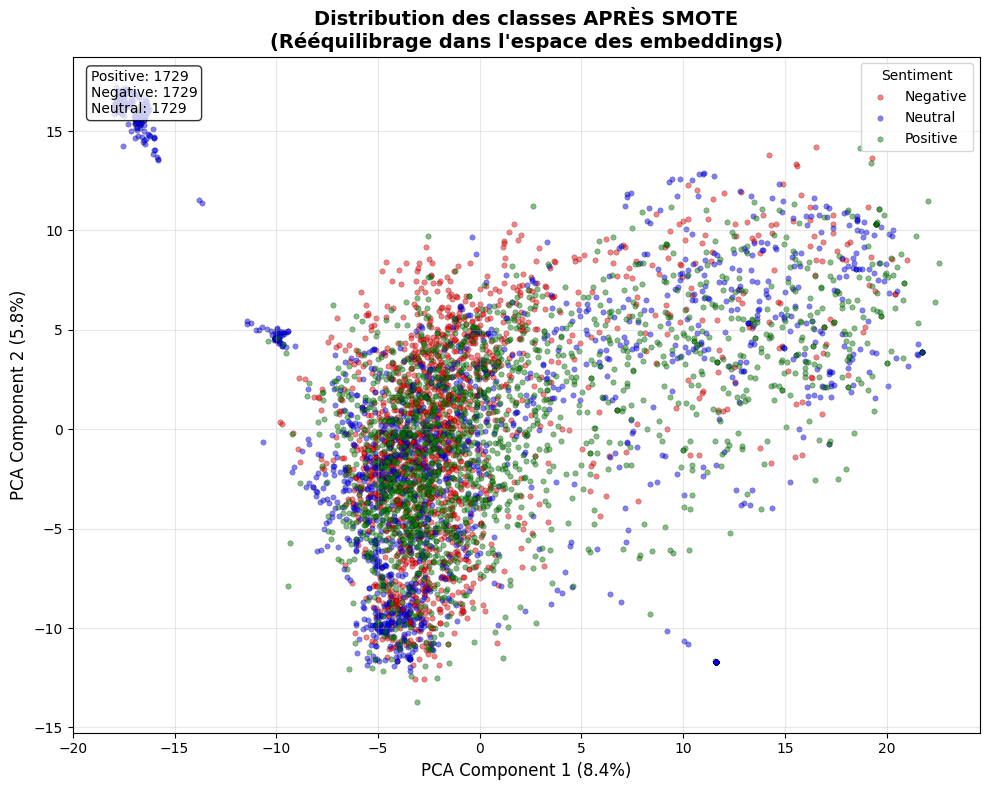


✓ Graphique sauvegardé: embeddings_apres_smote.png


In [48]:
# ============================================================
# VISUALISATION AVEC LA MEILLEURE CONFIGURATION SMOTE
# ============================================================

# Trouver la meilleure configuration (celle avec le meilleur F1-Neutral)
best_k_index = max(range(len(k_results)), key=lambda i: k_results[i]['f1_neutral'])
best_k = k_results[best_k_index]['k']

# Recréer SMOTE avec le meilleur k
from imblearn.over_sampling import SMOTE

smote_best = SMOTE(random_state=42, k_neighbors=best_k, sampling_strategy='auto')
X_smote_best, y_smote_best = smote_best.fit_resample(X_train_scaled, y_encoded)

print(f"Utilisation de la meilleure configuration: k={best_k}")

# Puis visualisation avec X_smote_best et y_smote_best
X_smote = X_smote_best
y_smote = y_smote_best

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

print("="*70)
print("VISUALISATION DES EMBEDDINGS APRÈS SMOTE")
print("(Pour la section 5.2 du rapport)")
print("="*70)

# Réduction PCA
pca = PCA(n_components=2, random_state=42)
X_smote_pca = pca.fit_transform(X_smote)

# Distribution après SMOTE
print("\nDistribution après SMOTE:")
unique, counts = np.unique(y_smote, return_counts=True)
for label, count in zip(unique, counts):
    print(f"  {le.inverse_transform([label])[0]}: {count} ({count/len(y_smote)*100:.1f}%)")

# Graphique
plt.figure(figsize=(10, 8))

colors = {0: 'red', 1: 'blue', 2: 'green'}
labels = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}

for label_id, color in colors.items():
    mask = y_smote == label_id
    plt.scatter(
        X_smote_pca[mask, 0],
        X_smote_pca[mask, 1],
        c=color,
        label=labels[label_id],
        alpha=0.5,
        s=15,
        edgecolors='black',
        linewidth=0.3
    )

plt.xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
plt.ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
plt.title('Distribution des classes APRÈS SMOTE\n(Rééquilibrage dans l\'espace des embeddings)',
          fontsize=14, fontweight='bold')
plt.legend(title='Sentiment', loc='best')
plt.grid(True, alpha=0.3)

# Ajouter les proportions
plt.text(0.02, 0.98, f'Positive: {np.sum(y_smote == 2)}\nNegative: {np.sum(y_smote == 0)}\nNeutral: {np.sum(y_smote == 1)}',
         transform=plt.gca().transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/embeddings_apres_smote.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Graphique sauvegardé: embeddings_apres_smote.png")

ANALYSE: Pourquoi SMOTE n'a pas amélioré les performances


/tmp/ipykernel_1512/1559139879.py:114: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(loc='upper right', fontsize=8)


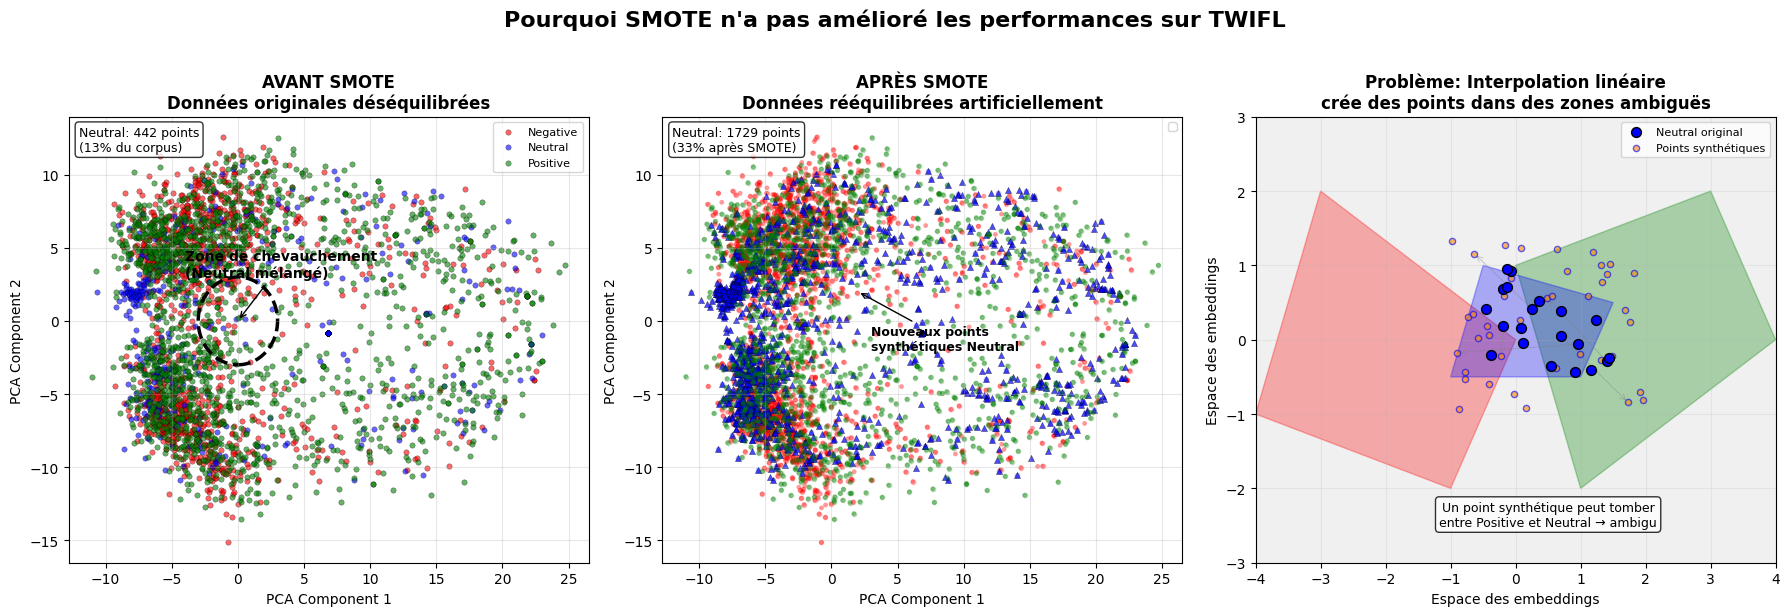

In [49]:
# ============================================================
# ANALYSE VISUELLE: Pourquoi SMOTE n'a pas fonctionné
# ============================================================

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle
from matplotlib.lines import Line2D

print("="*70)
print("ANALYSE: Pourquoi SMOTE n'a pas amélioré les performances")
print("="*70)

# ============================================================
# 1. Préparer les données AVANT et APRÈS SMOTE
# ============================================================

# Données originales
pca = PCA(n_components=2, random_state=42)
X_original_pca = pca.fit_transform(X_train_scaled)
X_smote_pca = pca.transform(X_smote)  # Utiliser le même PCA

# ============================================================
# 2. Créer une figure avec 3 sous-graphiques
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors_map = {0: 'red', 1: 'blue', 2: 'green'}
labels_map = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}

# ============================================================
# Graphique 1: Données originales (AVANT SMOTE)
# ============================================================

ax1 = axes[0]
for label_id, color in colors_map.items():
    mask = y_encoded == label_id
    ax1.scatter(
        X_original_pca[mask, 0],
        X_original_pca[mask, 1],
        c=color,
        label=labels_map[label_id],
        alpha=0.6,
        s=15,
        edgecolors='black',
        linewidth=0.3
    )

# Ajouter un cercle pour montrer la zone de chevauchement
circle = Circle((0, 0), 3, fill=False, edgecolor='black', linewidth=2.5, linestyle='--')
ax1.add_patch(circle)
ax1.annotate('Zone de chevauchement\n(Neutral mélangé)', xy=(0, 0), xytext=(-4, 3),
             fontsize=10, color='black', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='black'))

ax1.set_title('AVANT SMOTE\nDonnées originales déséquilibrées', fontsize=12, fontweight='bold')
ax1.set_xlabel('PCA Component 1', fontsize=10)
ax1.set_ylabel('PCA Component 2', fontsize=10)
ax1.legend(loc='upper right', fontsize=8)
ax1.grid(True, alpha=0.3)

# Annotations
neutral_count = np.sum(y_encoded == 1)
ax1.text(0.02, 0.98, f'Neutral: {neutral_count} points\n(13% du corpus)',
         transform=ax1.transAxes, fontsize=9, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ============================================================
# Graphique 2: Données APRÈS SMOTE
# ============================================================

ax2 = axes[1]

# Afficher d'abord les points originaux (en arrière-plan, plus clairs)
for label_id, color in colors_map.items():
    mask = y_encoded == label_id
    ax2.scatter(
        X_original_pca[mask, 0],
        X_original_pca[mask, 1],
        c=color,
        alpha=0.2,
        s=10,
    )

# Afficher les points SMOTE (en avant-plan)
for label_id, color in colors_map.items():
    mask = y_smote == label_id
    # Déterminer si ce sont des points originaux ou synthétiques
    alpha = 0.7 if label_id == 1 else 0.4
    size = 20 if label_id == 1 else 12
    marker = '^' if label_id == 1 else 'o'

    ax2.scatter(
        X_smote_pca[mask, 0],
        X_smote_pca[mask, 1],
        c=color,
        alpha=alpha,
        s=size,
        marker=marker,
        edgecolors='black' if label_id == 1 else 'none',
        linewidth=0.3
    )

# Ajouter une flèche pour montrer les nouveaux points
ax2.annotate('Nouveaux points\nsynthétiques Neutral', xy=(2, 2), xytext=(3, -2),
             fontsize=9, color='black', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='black'))

ax2.set_title('APRÈS SMOTE\nDonnées rééquilibrées artificiellement', fontsize=12, fontweight='bold')
ax2.set_xlabel('PCA Component 1', fontsize=10)
ax2.set_ylabel('PCA Component 2', fontsize=10)
ax2.legend(loc='upper right', fontsize=8)
ax2.grid(True, alpha=0.3)

neutral_count_smote = np.sum(y_smote == 1)
ax2.text(0.02, 0.98, f'Neutral: {neutral_count_smote} points\n(33% après SMOTE)',
         transform=ax2.transAxes, fontsize=9, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ============================================================
# Graphique 3: Illustration du problème (schéma explicatif)
# ============================================================

ax3 = axes[2]

# Schéma simplifié pour expliquer le problème
ax3.set_xlim(-4, 4)
ax3.set_ylim(-3, 3)
ax3.set_facecolor('#f0f0f0')

# Dessiner les zones
from matplotlib.patches import Polygon

# Zone Positive
pos_zone = Polygon([(1, -2), (4, 0), (3, 2), (0, 1)], alpha=0.3, color='green')
# Zone Negative
neg_zone = Polygon([(-4, -1), (-1, -2), (0, 0), (-3, 2)], alpha=0.3, color='red')
# Zone Neutral (petite zone entre les deux)
neu_zone = Polygon([(-1, -0.5), (1, -0.5), (1.5, 0.5), (-0.5, 1)], alpha=0.3, color='blue')

ax3.add_patch(pos_zone)
ax3.add_patch(neg_zone)
ax3.add_patch(neu_zone)

# Points originaux Neutral
np.random.seed(42)
orig_x = np.random.uniform(-0.5, 1.5, 20)
orig_y = np.random.uniform(-0.5, 1, 20)
ax3.scatter(orig_x, orig_y, c='blue', s=50, edgecolors='black', zorder=5, label='Neutral original')

# Points synthétiques (créés par interpolation)
synth_x = np.random.uniform(-1, 2, 40)
synth_y = np.random.uniform(-1, 1.5, 40)
ax3.scatter(synth_x, synth_y, c='darkorange', s=20, alpha=0.6, edgecolors='blue', zorder=4, label='Points synthétiques')

# Flèches d'interpolation
for i in range(5):
    ax3.annotate('', xy=(synth_x[i], synth_y[i]), xytext=(orig_x[i % 20], orig_y[i % 20]),
                 arrowprops=dict(arrowstyle='->', color='gray', alpha=0.5, lw=0.5))

# Légende personnalisée
ax3.set_title('Problème: Interpolation linéaire\ncrée des points dans des zones ambiguës',
              fontsize=12, fontweight='bold')
ax3.set_xlabel('Espace des embeddings', fontsize=10)
ax3.set_ylabel('Espace des embeddings', fontsize=10)
ax3.legend(loc='upper right', fontsize=8)
ax3.grid(True, alpha=0.2)

# Annotation
ax3.text(0.5, -2.5, 'Un point synthétique peut tomber\nentre Positive et Neutral → ambigu',
         fontsize=9, ha='center', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Pourquoi SMOTE n\'a pas amélioré les performances sur TWIFL',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/smote_analyse_pourquoi.png', dpi=150, bbox_inches='tight')
plt.show()